In [296]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
# import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))
res='1km'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [3]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [4]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    # W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [6]:
################################################################################

In [7]:
#out_arr

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_NEW.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
save=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_NEW.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out_arr=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_arr[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_arr[:,0] == elem)[0] 
    extras=idx[np.where(out_arr[idx,5]!=np.min(out_arr[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
out_arr=out_arr[mask]; 
###############################################################################

out_arr=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];print('list of first 10 ignored parcels');print(save_arr[:5])
placeholder=out_arr.copy(); run=True
############################################################
print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')


ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

list of first 10 SBZ parcels
[[74 41 47]
 [160 20 24]
 [232 18 21]
 [244 11 14]
 [363 11 14]
 [546 7 12]
 [566 28 32]
 [746 8 12]
 [750 24 29]
 [822 22 27]
 [827 26 30]
 [874 44 49]
 [885 59 65]
 [1028 8 12]
 [1189 10 13]]
list of first 10 ignored parcels
[[18 5 10]
 [218 22 27]
 [246 7 11]
 [357 14 20]
 [414 7 11]]
there are a total of 1290 CL parcels and 1473 nonCL parcels


In [8]:
#SHALLOW

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_arr=ALL_out_arr.copy()
    if type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_arr[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_arr=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_arr=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')


list of first 10 SBZ parcels
[[74 41 47]
 [160 20 24]
 [232 18 21]
 [244 11 14]
 [363 11 14]
 [546 7 12]
 [566 28 32]
 [746 8 12]
 [750 24 29]
 [822 22 27]
 [827 26 30]
 [874 44 49]
 [885 59 65]
 [1028 8 12]
 [1189 10 13]]
there are a total of 873 CL parcels and 1130 nonCL parcels


In [9]:
#DEEP

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_arr=ALL_out_arr.copy()
    if type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_arr[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=6 #4km
DEEP_out_arr=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_arr=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')

list of first 10 SBZ parcels
[[74 41 47]
 [160 20 24]
 [232 18 21]
 [244 11 14]
 [363 11 14]
 [546 7 12]
 [566 28 32]
 [746 8 12]
 [750 24 29]
 [822 22 27]
 [827 26 30]
 [874 44 49]
 [885 59 65]
 [1028 8 12]
 [1189 10 13]]
there are a total of 161 CL parcels and 167 nonCL parcels


In [507]:
Nx=len(data['xh'])
Ny=len(data['yh'])
def get_var(var,z_val,y_slice,x_slice):
    if var=='w':
        var_data=data[var].isel(time=ts[i],
                                yh=y_slice, xh=x_slice).interp(zf=data['zh']).isel(zh=z_val)
    else:
        var_data=data[var].isel(time=ts[i],zh=z_val,yh=y_slice,xh=x_slice)
    return var_data
    
def get_trajectory(var,row):
    #SETUP
    ######
    out_arr=ALL_out_arr
    box_size = 2
    after=4 #20 mins
    # t_mean=int(np.floor(np.mean(out_arr[:,2]+after+1-(out_arr[:,1]+1))))
    t_mean=9
    
    
    #GETTING INDICES
    ################
    p=out_arr[row,0]
    t1=out_arr[row,1]
    t2=out_arr[row,2]
    
    after=4 #20 mins
    ts=np.arange(t1,t2+after+1)
    zs=Z[t1:t2+after+1,p]
    ys=Y[t1:t2+after+1,p]
    xs=X[t1:t2+after+1,p]
    
    #MAKING DATA
    ############
    var_box=np.zeros((len(ts),5,5))

    # Skip parcels that cross the boundary
    if np.any((ys - box_size < 0) | (ys + box_size >= Ny) | 
          (xs - box_size < 0) | (xs + box_size >= Nx)):
        raise ValueError('Crossed Boundary')
        
    # Loop through each (xs, ys) pair and slice the data
    for i in range(len(ts)):
        # Extract the variable for the valid parcel
        var_box[i] = get_var(
            var, 
            zs[i], 
            slice(ys[i] - box_size, ys[i] + box_size + 1), 
            slice(xs[i] - box_size, xs[i] + box_size + 1)
        )
    
    #TIME INTERPOLATION
    ####################
    # Create interpolation function along axis 0 (time)
    interp_func = interp1d(np.linspace(0, 1, var_box.shape[0]), var_box, axis=0, kind='linear', fill_value='extrapolate')
    
    # Interpolate to new time steps
    var_box_interp = interp_func(np.linspace(0, 1, t_mean))
    
    return var_box,var_box_interp

[var_box1,var_box_interp1]=get_trajectory(var='w',row=10)

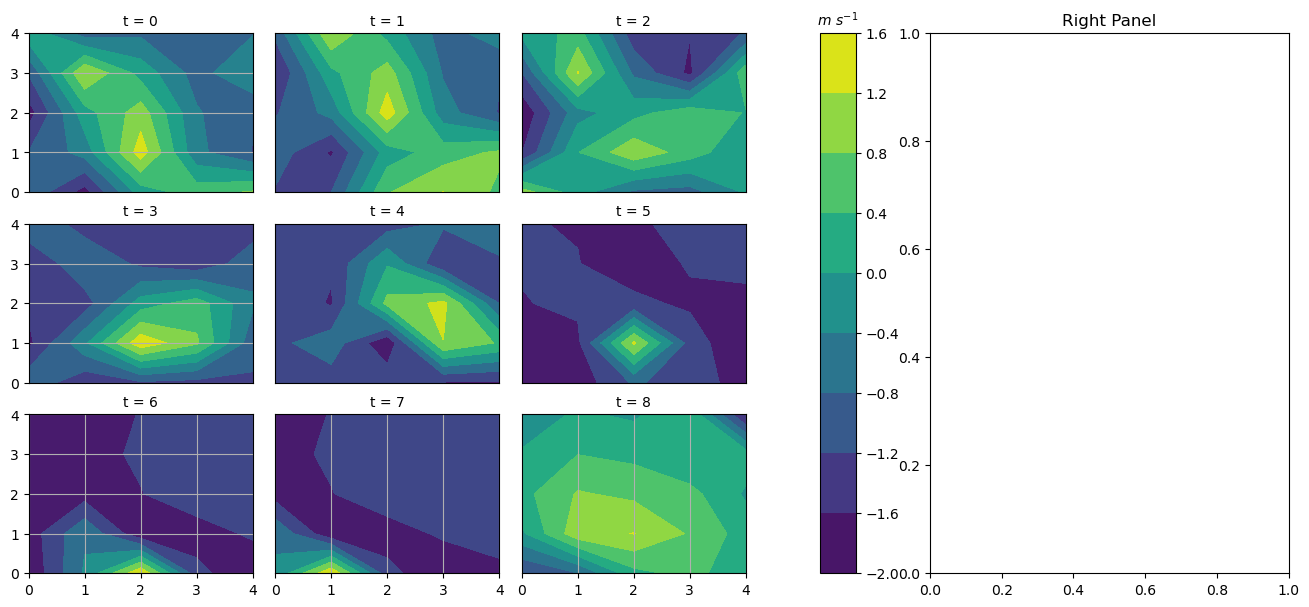

In [583]:
# Create figure and main gridspec (1 row, 3 columns)
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(1, 3, width_ratios=[2, 0.1, 1], figure=fig, wspace=0.2)  # Reduce space between left and middle panel

# Create a 3x3 gridspec within the left panel
gs_left = GridSpecFromSubplotSpec(3, 3, subplot_spec=gs[0, 0], wspace=0.1, hspace=0.2)

# Loop over timesteps and create subplots in 3x3 format (left to right, top to bottom)
for t in range(9):
    row, col = divmod(t, 3)  # Get row, column indices for 3x3 layout
    ax = fig.add_subplot(gs_left[row, col])
    im = ax.contourf(var_box_interp1[t], cmap='viridis')
    ax.set_title(f't = {t}', fontsize=10)
    ax.grid(True) #***
    
    # Show y-axis only for the leftmost plots
    if col == 0:
        ax.set_yticks(range(var_box_interp1.shape[1]))
    else:
        ax.set_yticks([])

    # Show x-axis only for the bottom row
    if row == 2:
        ax.set_xticks(range(var_box_interp1.shape[2]))
    else:
        ax.set_xticks([])

# Middle panel: Create a subplot for the colorbar
ax_cbar = fig.add_subplot(gs[0, 1])  # Use the middle narrow panel
cbar = fig.colorbar(im, cax=ax_cbar)
ax_cbar.set_title(get_unit(var), fontsize=10)

# Right panel placeholder
ax_right = fig.add_subplot(gs[0, 2])
ax_right.set_title("Right Panel")

# Adjust figure spacing
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95)



In [331]:
# #TESTING
# plt.contourf(var_box1[1]-var_box_interp1[1])
# plt.colorbar()

In [288]:
########################################################################

In [514]:
Nx=len(data['xh'])
Ny=len(data['yh'])
def get_var(var,z_val,y_slice,x_slice):
    if var=='w':
        var_data=data[var].isel(time=ts[i],
                                yh=y_slice, xh=x_slice).interp(zf=data['zh']).isel(zh=z_val)
    else:
        var_data=data[var].isel(time=ts[i],zh=z_val,yh=y_slice,xh=x_slice)
    return var_data

def get_mean_trajectory(var):
    #SETUP
    ######
    # out_arr=ALL_out_arr
    out_arr=DEEP_out_arr
    box_size = 2
    after=4 #20 mins
    # t_mean=int(np.floor(np.mean(out_arr[:,2]+after+1-(out_arr[:,1]+1))))
    t_mean=9
    var_box_interp=np.zeros((t_mean,5,5))

    for row in np.arange(out_arr.shape[0]):
        if np.mod(row,10)==0: print(f'current row {row}')
        
        #GETTING INDICES
        ################
        p=out_arr[row,0]
        t1=out_arr[row,1]
        t2=out_arr[row,2]
        
        after=4 #20 mins
        ts=np.arange(t1,t2+after+1)
        zs=Z[t1:t2+after+1,p]
        ys=Y[t1:t2+after+1,p]
        xs=X[t1:t2+after+1,p]
        
        #MAKING DATA
        ############
        var_box=np.zeros((len(ts),5,5))
    
        # Skip parcels that cross the boundary
        if np.any((ys - box_size < 0) | (ys + box_size >= Ny) | 
              (xs - box_size < 0) | (xs + box_size >= Nx)):
            continue
            
        # Loop through each (xs, ys) pair and slice the data
        for i in range(len(ts)):
            # Extract the variable for the valid parcel
            var_box[i] = get_var(
                var, 
                zs[i], 
                slice(ys[i] - box_size, ys[i] + box_size + 1), 
                slice(xs[i] - box_size, xs[i] + box_size + 1))
            
        #TIME INTERPOLATION
        ####################
        # Create interpolation function along axis 0 (time)
        interp_func = interp1d(np.linspace(0, 1, var_box.shape[0]), var_box, axis=0, kind='linear', fill_value='extrapolate')
        
        # Interpolate to new time steps
        var_box_interp += interp_func(np.linspace(0, 1, t_mean))

    var_box_interp/=out_arr.shape[0]
    return var_box_interp

var='w'
var_box_interp=get_mean_trajectory(var=var)

current row 0
current row 10
current row 20
current row 30
current row 40
current row 50
current row 60
current row 70
current row 80
current row 90
current row 100
current row 110
current row 120
current row 130
current row 140
current row 150
current row 160


In [ ]:
def get_unit(var):
    variables = data.variables
    long_names = {var: {
            'long_name': data[var].attrs.get('long_name', ''),
            'units': data[var].attrs.get('units', '')
        } for var in variables}


    w_vars = {var: long_name for var, long_name in long_names.items() if var.startswith('wb') or var in ['w']}
    ptb_vars = {var: long_name for var, long_name in long_names.items() if var.startswith('ptb') or var in ['th']}
    qvb_vars = {var: long_name for var, long_name in long_names.items() if var.startswith('qvb') or var in ['qv']}
    vars = {}
    vars.update(w_vars)
    vars.update(ptb_vars)
    vars.update(qvb_vars)
    
    
    var_names=list(vars.keys())
    long_names = [info['long_name'] for info in vars.values()]
    units = [info['units'] for info in vars.values()]
    def convert_to_latex(unit):
        parts = unit.split('/')  # Split the unit into parts
        latex_unit = parts[0]  # Start with the first part
        for part in parts[1:]:  # Iterate over the remaining parts
            latex_unit += r"\ " + part + r"^{-1}"  # Add the part with a '^{-1}' exponent
        return r"$" + latex_unit + r"$"
    latex_units = [convert_to_latex(unit) for unit in units]
    
    where=np.where(np.array(list(vars.keys()))==var)[0]
    final_unit=np.array(latex_units)[where][0]
    return final_unit

get_unit('w')

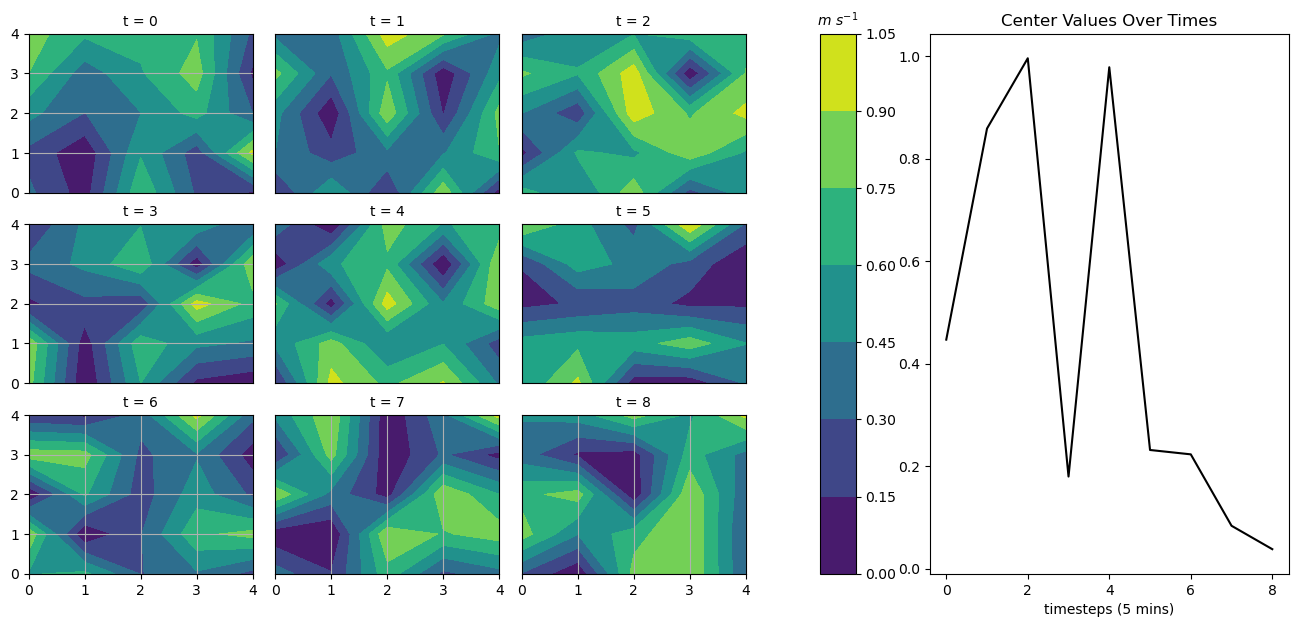

In [590]:
# Create figure and main gridspec (1 row, 3 columns)
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(1, 3, width_ratios=[2, 0.1, 1], figure=fig, wspace=0.2)  # Reduce space between left and middle panel

# Create a 3x3 gridspec within the left panel
gs_left = GridSpecFromSubplotSpec(3, 3, subplot_spec=gs[0, 0], wspace=0.1, hspace=0.2)

# Loop over timesteps and create subplots in 3x3 format (left to right, top to bottom)
for t in range(9):
    row, col = divmod(t, 3)  # Get row, column indices for 3x3 layout
    ax = fig.add_subplot(gs_left[row, col])
    im = ax.contourf(var_box_interp[t], cmap='viridis')
    ax.set_title(f't = {t}', fontsize=10)
    ax.grid(True) #***
    
    # Show y-axis only for the leftmost plots
    if col == 0:
        ax.set_yticks(range(var_box_interp.shape[1]))
    else:
        ax.set_yticks([])

    # Show x-axis only for the bottom row
    if row == 2:
        ax.set_xticks(range(var_box_interp.shape[2]))
    else:
        ax.set_xticks([])

# Middle panel: Create a subplot for the colorbar
ax_cbar = fig.add_subplot(gs[0, 1])  # Use the middle narrow panel
cbar = fig.colorbar(im, cax=ax_cbar)
ax_cbar.set_title(get_unit(var), fontsize=10)

# Right panel placeholder
ax_right = fig.add_subplot(gs[0, 2])
ax_right.set_title("Center Values Over Times")

ax_right.plot(var_box_interp[:,2,2],color='black');
ax_right.set_xlabel(f'timesteps (5 mins)')

# Adjust figure spacing
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95)

